# ETL, Plots and Storytelling Project. PART 2

For this projet, we will work with real-world data and engage our audience (business stakeholders and decision-makers) through a range of visualizations and reports.

The project is structured into five sections:

Section 1 – Sales Trend Over Time. \
Section 2 – Grouping and Summarization. \
Section 3 – Payment Analysis. \
Section 4 – Customer Satisfaction Level. \
Section 5 – Marketing Analytics Metrics. 

This is an extensive project, involving a large number of analyses in Python. The visualizations depend on the data, so we will preprocess and adjust the data before creating each chart. For each section, we will address multiple business questions using visualizations and storytelling.

This is a project made of 3 parts, this is the second one. 

Loading Libraries

In [158]:
# Imports
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px
import colorlover as cl
from matplotlib import style
from datetime import datetime, timedelta
from plotly.offline import init_notebook_mode, iplot
from plotly import tools
import warnings
warnings.filterwarnings('ignore')

## Loading and understanding data

In [159]:
# Loading dataset

FILE_ID = "1ikA5f7Y6ccuy1pPlR6kV569p4xtQoo05"

url = f"https://drive.google.com/uc?id={FILE_ID}"

df = pd.read_csv(url)

In [160]:
# Shape

df.shape

(116581, 53)

In [161]:
# Data Sample

df.sample(10)

,order_id,order_id3,customer_id3,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,seller_city,seller_state,product_category_name_english,review_response_time,order_purchase_year,order_purchase_month,order_purchase_dayofweek,order_purchase_hour,order_purchase_day,order_purchase_mon
15371,ON08710,bcaeee361335dfff837f461e0e3011e1,acfa23831b953d3b1891f6f164e78a0e,delivered,2017-08-29 20:40:44,2017-08-29 20:55:08,2017-08-30 20:43:43,2017-09-05 21:08:08,2017-09-20 00:00:00,1.0,...,Rio Do Sul,SC,sports leisure,1.0,2017,8,1,20,Tue,Aug
10787,ON43585,842e1880e0859a810c436d8576aab76b,992ff4367edf788b631d051cfd336b61,delivered,2018-05-01 12:07:08,2018-05-01 12:34:20,2018-05-03 06:31:00,2018-05-04 21:38:52,2018-05-15 00:00:00,1.0,...,Sao Paulo,SP,cool stuff,3.0,2018,5,1,12,Tue,May
8461,ON28975,a26a698877ae127304d51b9da20bc1ff,2456c34ff4ea4f59234ae9fc04adfe68,delivered,2017-12-17 10:42:27,2017-12-17 11:14:15,2017-12-18 15:53:38,2018-01-03 19:52:21,2018-01-18 00:00:00,1.0,...,Belo Horizonte,MG,baby,5.0,2017,12,6,10,Sun,Dec
42540,ON78037,309f6784abccce4e6e99672dca8ff4cd,b0f06b1979dedd3f28f8f0d5e4ad08fb,delivered,2018-08-07 00:47:40,2018-08-08 07:05:11,2018-08-09 12:23:00,2018-08-10 17:51:57,2018-08-10 00:00:00,1.0,...,Sao Bernardo Do Campo,SP,health beauty,0.0,2018,8,1,0,Tue,Aug
64026,ON53664,39b203e1add14efaa6f3dc4b38daa49b,570955d725f29b313e9e7a73ee1a2c1d,delivered,2018-05-13 16:27:52,2018-05-13 16:53:39,2018-05-22 11:07:00,2018-06-04 18:06:34,2018-06-21 00:00:00,1.0,...,Belo Horizonte,MG,watches gifts,0.0,2018,5,6,16,Sun,May
13556,ON09905,8207dc60d7f55f4ac2b9601f02eeff29,93d5fd8f7db0fa4ca0ed24b83f12505b,delivered,2018-06-02 19:52:07,2018-06-02 20:12:16,2018-06-04 14:02:00,2018-06-14 18:50:01,2018-07-24 00:00:00,1.0,...,Sao Paulo,SP,cool stuff,2.0,2018,6,5,19,Sat,Jun
83559,ON65068,c84ef2a01e44394c9dfef910a4c70df5,2807ccb86c70a612c783f4d658dd8848,delivered,2017-11-10 11:45:58,2017-11-10 12:09:45,2017-11-10 21:06:32,2017-11-22 00:04:42,2017-12-06 00:00:00,1.0,...,Sao Paulo,SP,stationery,0.0,2017,11,4,11,Fri,Nov
88537,ON93202,44dc0411086c2f8c6b692be9ce3120eb,a0561b2c7966b97f7f00862466db854c,delivered,2018-02-13 11:58:53,2018-02-15 03:55:26,2018-02-20 19:22:37,2018-02-24 00:46:46,2018-03-06 00:00:00,1.0,...,Sao Jose Do Rio Preto,SP,garden tools,1.0,2018,2,1,11,Tue,Feb
106139,ON70095,ba3a333397102140e9240fd17ff05e4b,7db0da9613a8abf3df20bc935908ac87,delivered,2018-02-18 15:35:00,2018-02-20 07:27:52,2018-02-22 19:32:59,2018-03-11 17:48:24,2018-03-12 00:00:00,1.0,...,Brasilia,DF,bed bath table,0.0,2018,2,6,15,Sun,Feb
5269,ON93728,c308d0d781ddbf00ef974e5dfd79d746,2c2c6d6306525aa4e3b0508924c7e553,delivered,2017-04-23 11:12:58,2017-04-25 07:55:48,2017-04-25 14:05:41,2017-05-01 12:36:47,2017-05-11 00:00:00,1.0,...,Sao Paulo,SP,housewares,0.0,2017,4,6,11,Sun,Apr


## Section 2 - Grouping and Summarization

### Feature Extraction

In this stage, new columns will be created by combining and transforming existing variables to generate additional features.

In [162]:
# Preparing Data

date_columns = ['order_purchase_timestamp', 
                'order_approved_at', 
                'order_delivered_carrier_date', 
                'order_delivered_customer_date',
                'order_estimated_delivery_date', 
                'shipping_limit_date', 
                'review_creation_date', 
                'review_answer_timestamp'] 

In [163]:
# Loop to Format the Dates

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format = '%Y-%m-%d %H:%M:%S')

In [164]:
# Create a column named 'order_process_time' to measure the time elapsed
# from when the customer places the order to when it is delivered.

df['order_process_time'] = df['order_delivered_customer_date'] - df['order_purchase_timestamp']

In [165]:
# Create a column named 'order_delivery_time' to measure how long each order took to be delivered

df['order_delivery_time'] = df['order_delivered_customer_date'] - df['order_delivered_carrier_date']

In [166]:
# Create an 'order_time_accuracy' column to evaluate whether the estimated delivery time was accurate
# Positive values indicate early delivery, 0 indicates on-time delivery, and negative values indicate late delivery.

df['order_accuracy_time'] = df['order_estimated_delivery_date'] - df['order_delivered_customer_date']

In [167]:
df.head()

,order_id,order_id3,customer_id3,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,review_response_time,order_purchase_year,order_purchase_month,order_purchase_dayofweek,order_purchase_hour,order_purchase_day,order_purchase_mon,order_process_time,order_delivery_time,order_accuracy_time
0,ON34305,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,...,1.0,2017,10,0,10,Mon,Oct,8 days 10:28:40,6 days 01:30:13,7 days 02:34:47
1,ON34305,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,...,1.0,2017,10,0,10,Mon,Oct,8 days 10:28:40,6 days 01:30:13,7 days 02:34:47
2,ON34305,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,...,1.0,2017,10,0,10,Mon,Oct,8 days 10:28:40,6 days 01:30:13,7 days 02:34:47
3,ON40291,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28,1.0,...,1.0,2017,8,1,18,Tue,Aug,2 days 20:15:12,0 days 23:16:10,9 days 09:15:17
4,ON74313,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02 18:24:47,2017-08-02 18:43:15,2017-08-04 17:35:43,2017-08-07 18:30:01,2017-08-15,1.0,...,0.0,2017,8,2,18,Wed,Aug,5 days 00:05:14,3 days 00:54:18,7 days 05:29:59


### Question 2.1 – Top 20 Best-Selling Product Categories

In [168]:
# Top 20 Best-Selling Product Categories

top_20_bestselling_product_categories = df['order_item_id'] \
                                .groupby(df['product_category_name_english']) \
                                .count().sort_values(ascending = False)[:20]

In [169]:
# List the first 5 results.

top_20_bestselling_product_categories.head()

product_category_name_english
bed bath table           11990
health beauty            10030
sports leisure            9005
furniture decor           8833
computers accessories     8151
Name: order_item_id, dtype: int64

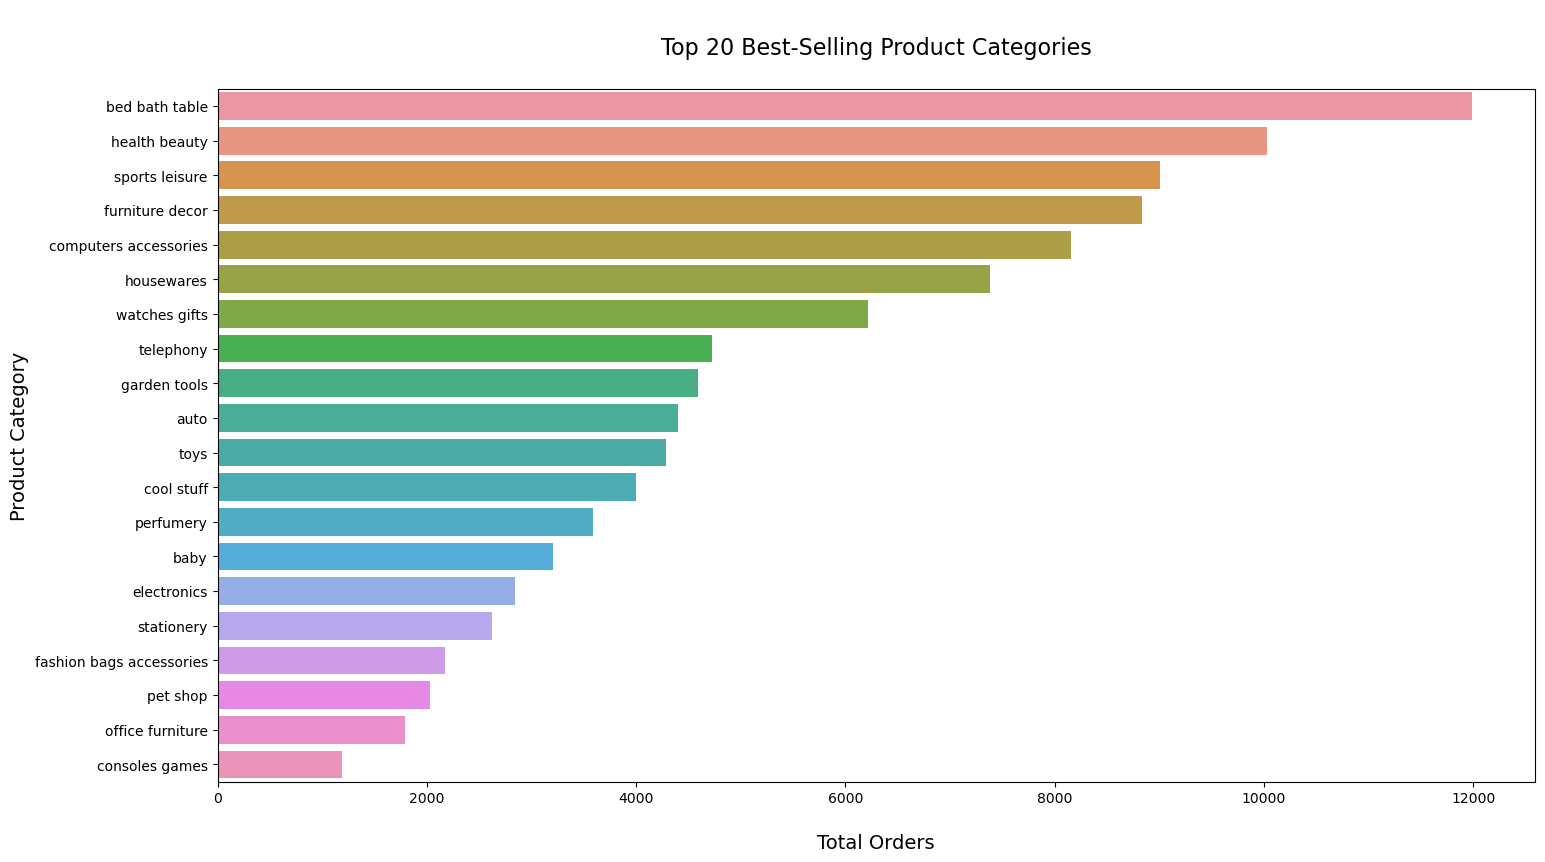

In [170]:
# Plot
fig = plt.figure(figsize = (17,9))
sns.barplot(y = top_20_bestselling_product_categories.index, x = top_20_bestselling_product_categories.values)
plt.title('\nTop 20 Best-Selling Product Categories\n', fontsize = 16)
plt.xlabel('\nTotal Orders', fontsize = 14)
plt.ylabel('Product Category', fontsize = 14)
plt.show();

### Question 2.2 - Top 20 Cities with the Highest Sales

In [171]:
# Top 20 Cities with the Highest Sales Volume

top_20_cities_with_the_highest_sales = df['order_item_id'] \
                             .groupby(df['customer_city']) \
                             .count().sort_values(ascending = False)[:20]

In [172]:
# List the first 5 results.

top_20_cities_with_the_highest_sales.head()

customer_city
Sao Paulo         18412
Rio De Janeiro     8123
Belo Horizonte     3218
Brasilia           2452
Curitiba           1799
Name: order_item_id, dtype: int64

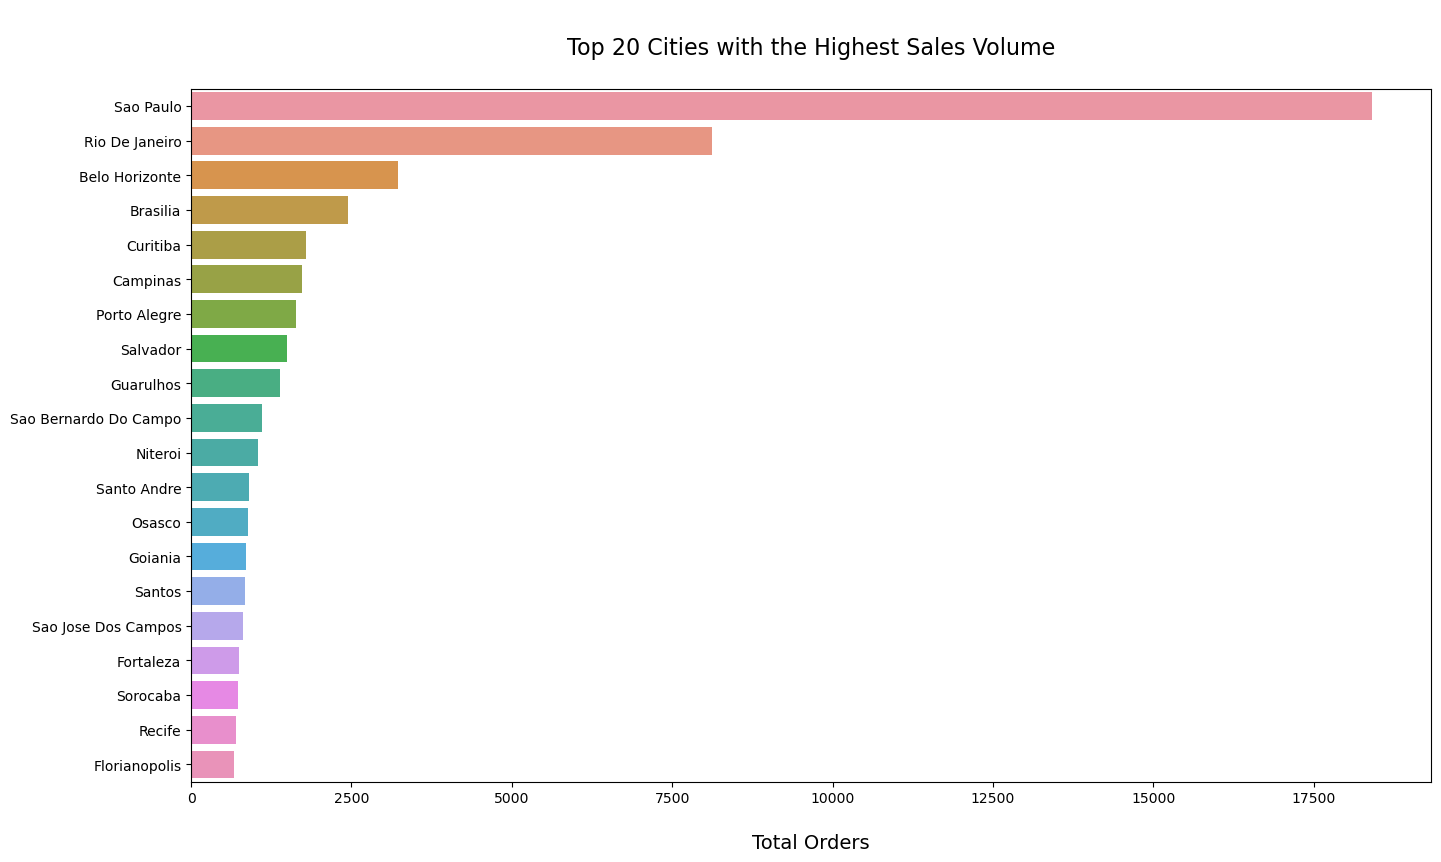

In [173]:
# Plot

fig = plt.figure (figsize = (16,9))
sns.barplot(y = top_20_cities_with_the_highest_sales.index, x = top_20_cities_with_the_highest_sales.values)
plt.title('\nTop 20 Cities with the Highest Sales Volume\n', fontsize = 16)
plt.xlabel('\nTotal Orders', fontsize = 14)
plt.ylabel('', fontsize = 14)
plt.show();

### Question 2.3 – What Is the Median Delivery Time by Month Over Time?

We will use the median instead of the mean to reduce the impact of outliers.

In [174]:
# the Median Delivery Time by Month Over Time

df['Month_order'] = df['order_purchase_timestamp'].dt.to_period('M').astype('str')

In [175]:
# Group by month and compute the median using only the numeric component of the date

delivery_time_by_month = df['order_delivery_time'].groupby(df['Month_order']).median(numeric_only = False)

In [176]:
# List the first 5 results.

delivery_time_by_month.head()

Month_order
2016-09          7 days 01:30:53
2016-10          4 days 21:08:03
2016-12          1 days 09:40:17
2017-01   7 days 02:18:37.500000
2017-02          7 days 05:03:05
Name: order_delivery_time, dtype: timedelta64[ns]

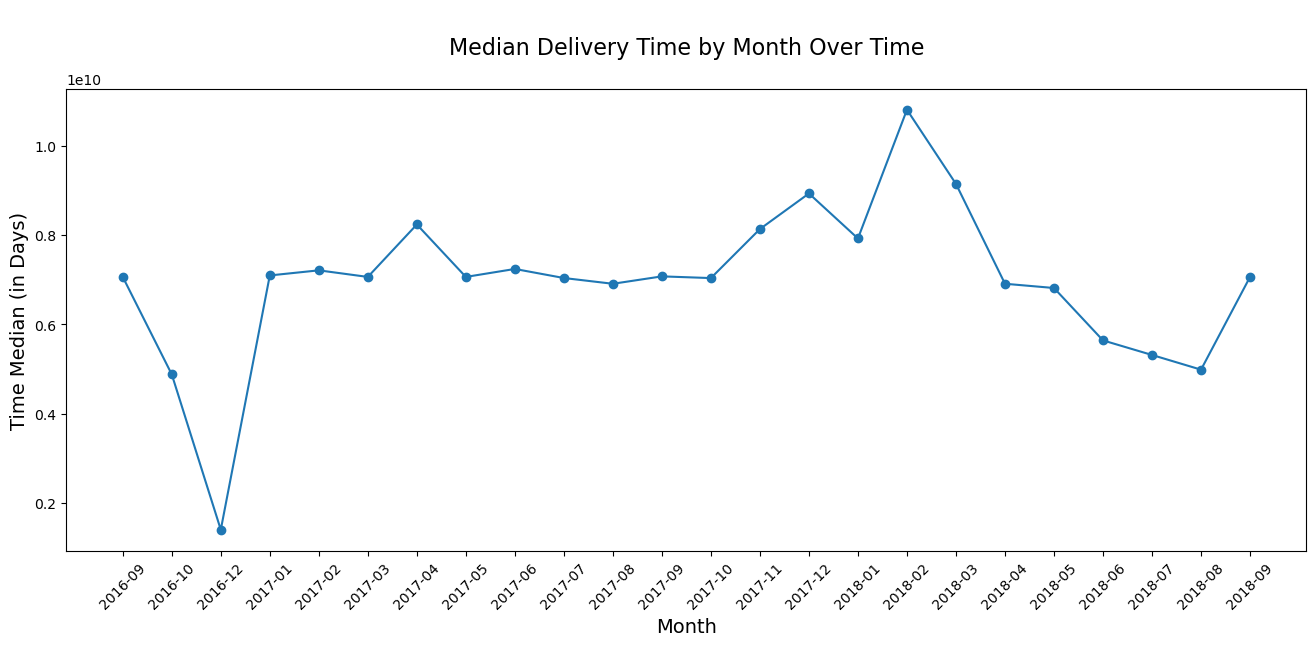

In [177]:
# Plot
fig = plt.figure (figsize = (16,6))
plt.plot(delivery_time_by_month.index, delivery_time_by_month.values / 86400, marker = 'o')
plt.title('\nMedian Delivery Time by Month Over Time\n', fontsize = 16)
plt.xlabel('Month', fontsize = 14)
plt.xticks(rotation = 45)
plt.ylabel('Time Median (in Days)', fontsize = 14)
plt.show();

### Question 2.4 - What Is the Median Estimated Delivery Time by Month?

In [178]:
df.columns

Index(['order_id', 'order_id3', 'customer_id3', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id3',
       'seller_id3', 'shipping_limit_date', 'price', 'freight_value',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_id3', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'product_id',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_id', 'customer_unique_id', 'customer_uniqueid3',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'seller_id', 'seller_zip_code_prefix', 'seller_city', '

In [179]:
df['Month_order'].head()

0    2017-10
1    2017-10
2    2017-10
3    2017-08
4    2017-08
Name: Month_order, dtype: object

In [180]:
# Median of the Final Estimated Delivery Time to the Customer per Order by Month

accuracy_time_by_month = df['order_accuracy_time'].groupby(df['Month_order']).median(numeric_only = False) 

In [181]:
# List the first 5 results.

accuracy_time_by_month.head()

Month_order
2016-09         -6 days +09:14:16
2016-10   40 days 01:13:15.500000
2016-12          21 days 08:05:16
2017-01          28 days 11:27:27
2017-02          19 days 09:55:18
Name: order_accuracy_time, dtype: timedelta64[ns]

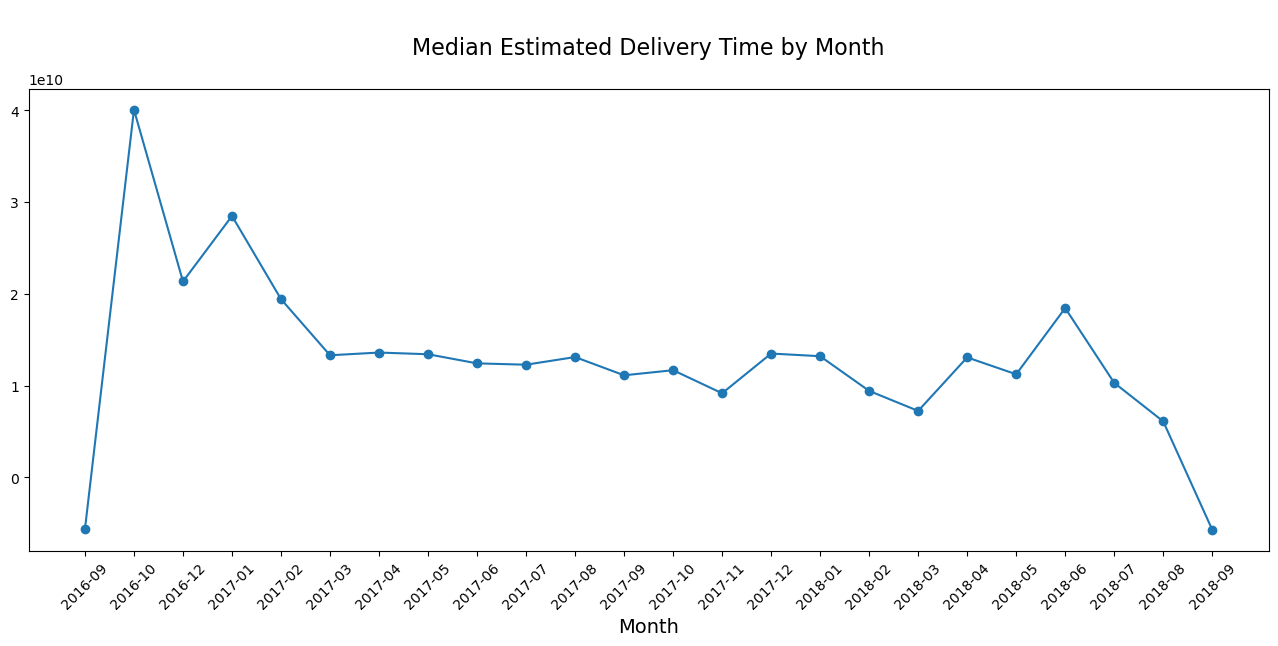

In [182]:
# Plot

fig = plt.figure (figsize = (16,6))
plt.plot(accuracy_time_by_month.index, accuracy_time_by_month.values / 86400, marker = 'o')
plt.title('\nMedian Estimated Delivery Time by Month\n', fontsize = 16)
plt.xlabel('Month', fontsize = 14)
plt.xticks(rotation = 45)
plt.ylabel('', fontsize = 14)
plt.show();

### Question 2.5 - What Are the Top 10 Product Categories with the Shortest Order-to-Delivery Time?

In [183]:
df['product_category_name_english'].sample(5)

31670                             furniture decor
29681                             furniture decor
113068    kitchen dining laundry garden furniture
15523                              sports leisure
65634                                 electronics
Name: product_category_name_english, dtype: object

In [184]:
# Top 10 Product Categories with the Shortest Time from Order Placement to Customer Acceptance

order_time_by_category = pd.DataFrame(df['order_process_time'] \
                                      .groupby(df['product_category_name_english']) \
                                      .min().sort_values(ascending = True)[:10])

In [185]:
# List the first 5 results.

order_time_by_category.head()

,order_process_time
product_category_name_english,
toys,0 days 12:48:07
housewares,0 days 18:45:10
bed bath table,0 days 20:31:39
cool stuff,0 days 21:22:41
baby,0 days 21:25:11


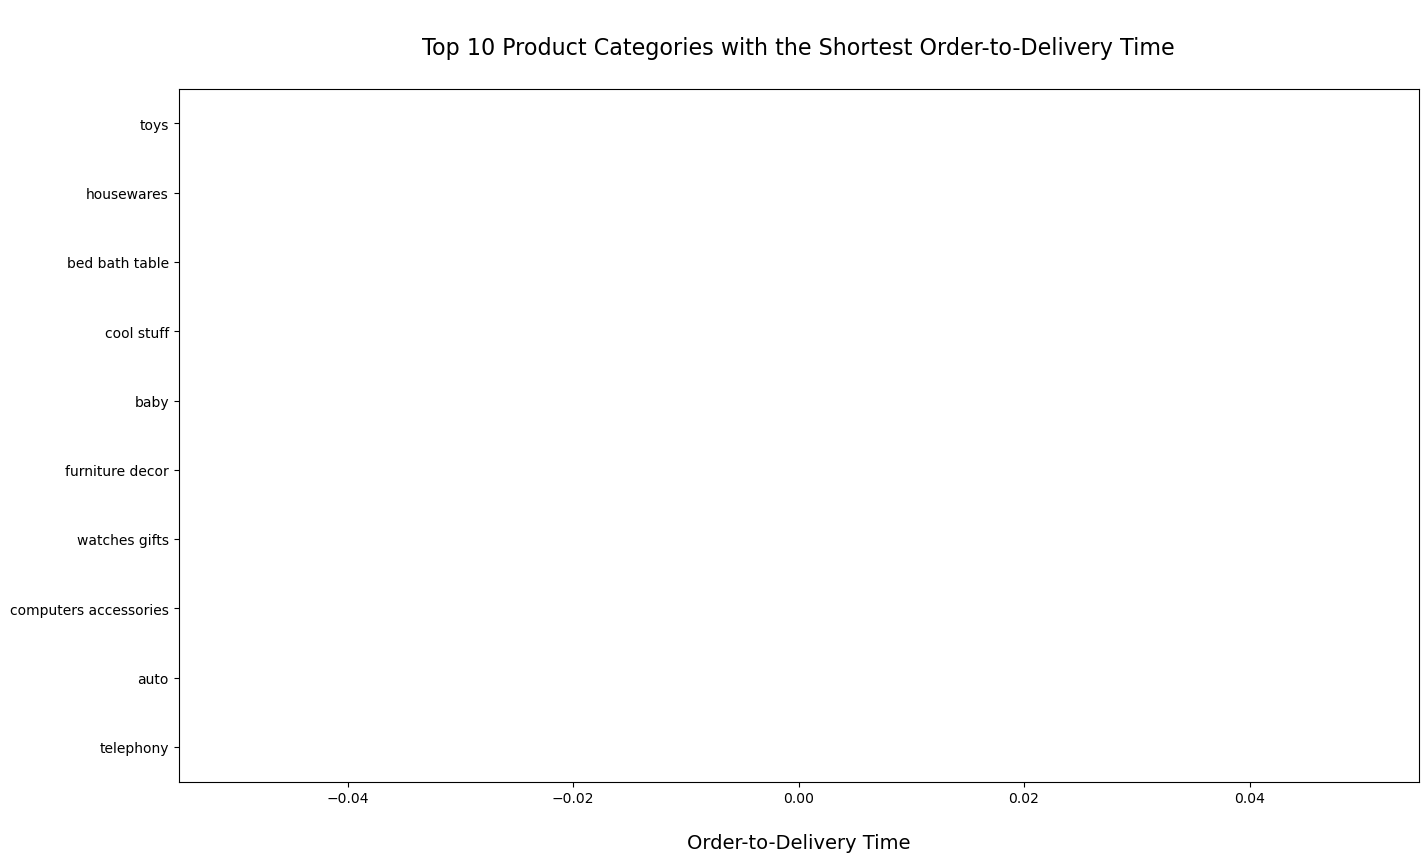

In [186]:
# Plot
fig = plt.figure (figsize = (16,9))
sns.barplot(y = order_time_by_category.index, x = order_time_by_category['order_process_time'].dt.days)
plt.title('\nTop 10 Product Categories with the Shortest Order-to-Delivery Time\n', fontsize = 16)
plt.xlabel('\nOrder-to-Delivery Time', fontsize = 14)
plt.ylabel('', fontsize = 14)
plt.show();

The plot is empty because the 10 fastest values of 'order_time_by_category' are expressed in hours rather than days. We need to convert them first.

In [187]:
# Calculate time in hours

order_time_by_category['order_process_time_hours'] = order_time_by_category['order_process_time'].dt.total_seconds() / 3600

In [188]:
# List the last 5 results

order_time_by_category.tail()

,order_process_time,order_process_time_hours
product_category_name_english,,
furniture decor,0 days 22:27:49,22.463611
watches gifts,0 days 22:30:59,22.516389
computers accessories,0 days 23:37:30,23.625000
auto,0 days 23:39:18,23.655000
telephony,0 days 23:43:45,23.729167


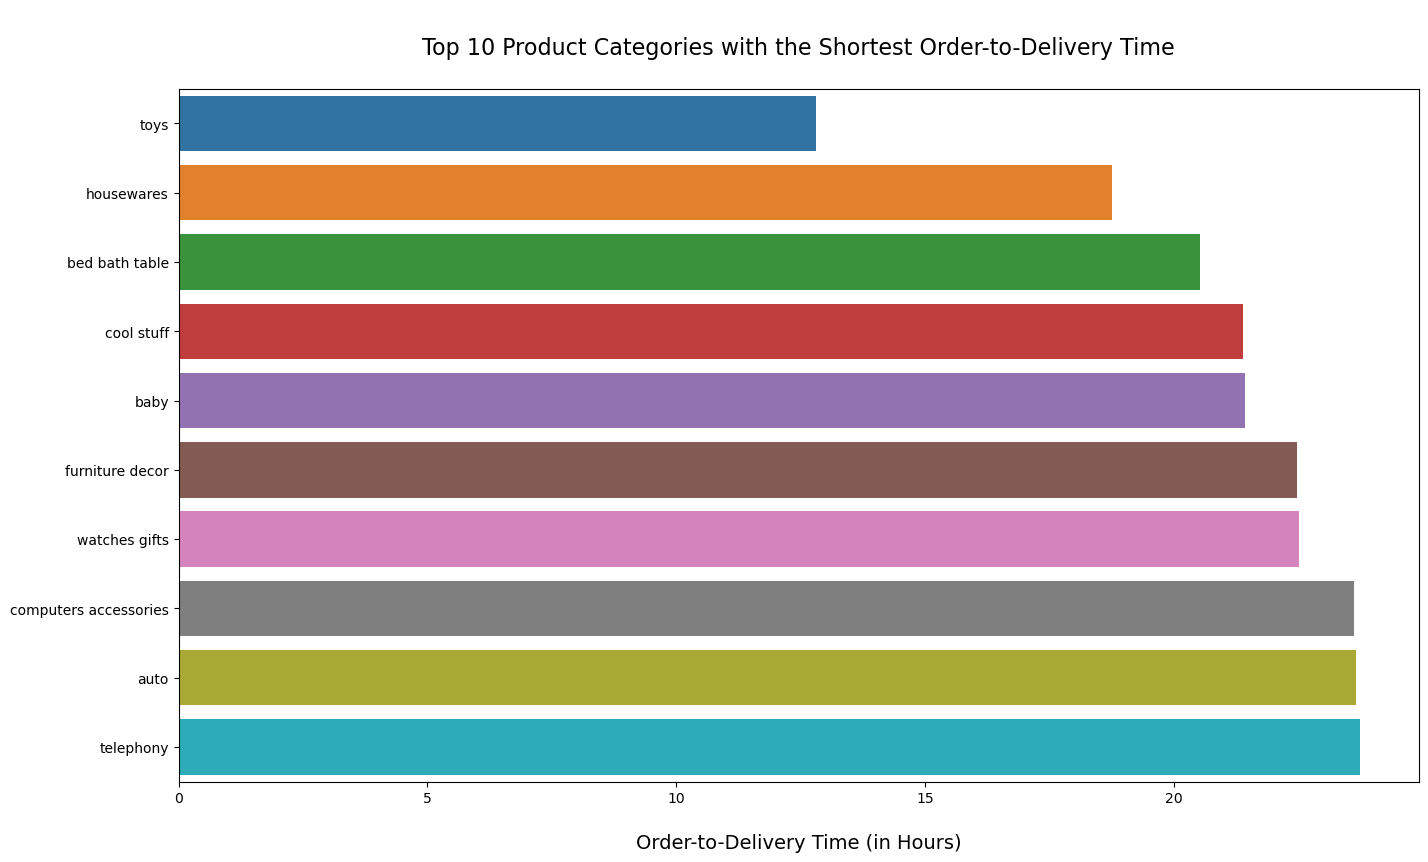

In [189]:
# Plot
fig = plt.figure (figsize = (16,9))
sns.barplot(y = order_time_by_category.index, x = order_time_by_category['order_process_time_hours'])
plt.title('\nTop 10 Product Categories with the Shortest Order-to-Delivery Time\n', fontsize = 16)
plt.xlabel('\nOrder-to-Delivery Time (in Hours)', fontsize = 14)
plt.ylabel('', fontsize = 14)
plt.show();

### Question 2.6 - What Are the Top 10 Product Categories with the Longest Order-to-Delivery Time?

In [190]:
# Top 10 Product Categories with the Longest Order-to-Delivery Time

order_time_by_category = pd.DataFrame (df['order_process_time'] \
                                       .groupby(df['product_category_name_english']) \
                                       .max().sort_values(ascending = False)[:10])

In [191]:
# List the first 5 results.

order_time_by_category.head()

,order_process_time
product_category_name_english,
auto,209 days 15:05:12
cool stuff,208 days 08:26:32
consoles games,195 days 15:12:59
office furniture,194 days 20:24:15
musical instruments,194 days 15:12:24


In [192]:
# List the last 5 results

order_time_by_category.tail()

,order_process_time
product_category_name_english,
watches gifts,194 days 01:11:24
home construction,191 days 11:07:30
furniture decor,189 days 20:42:57
home appliances 2,187 days 17:51:08
computers accessories,182 days 15:47:43


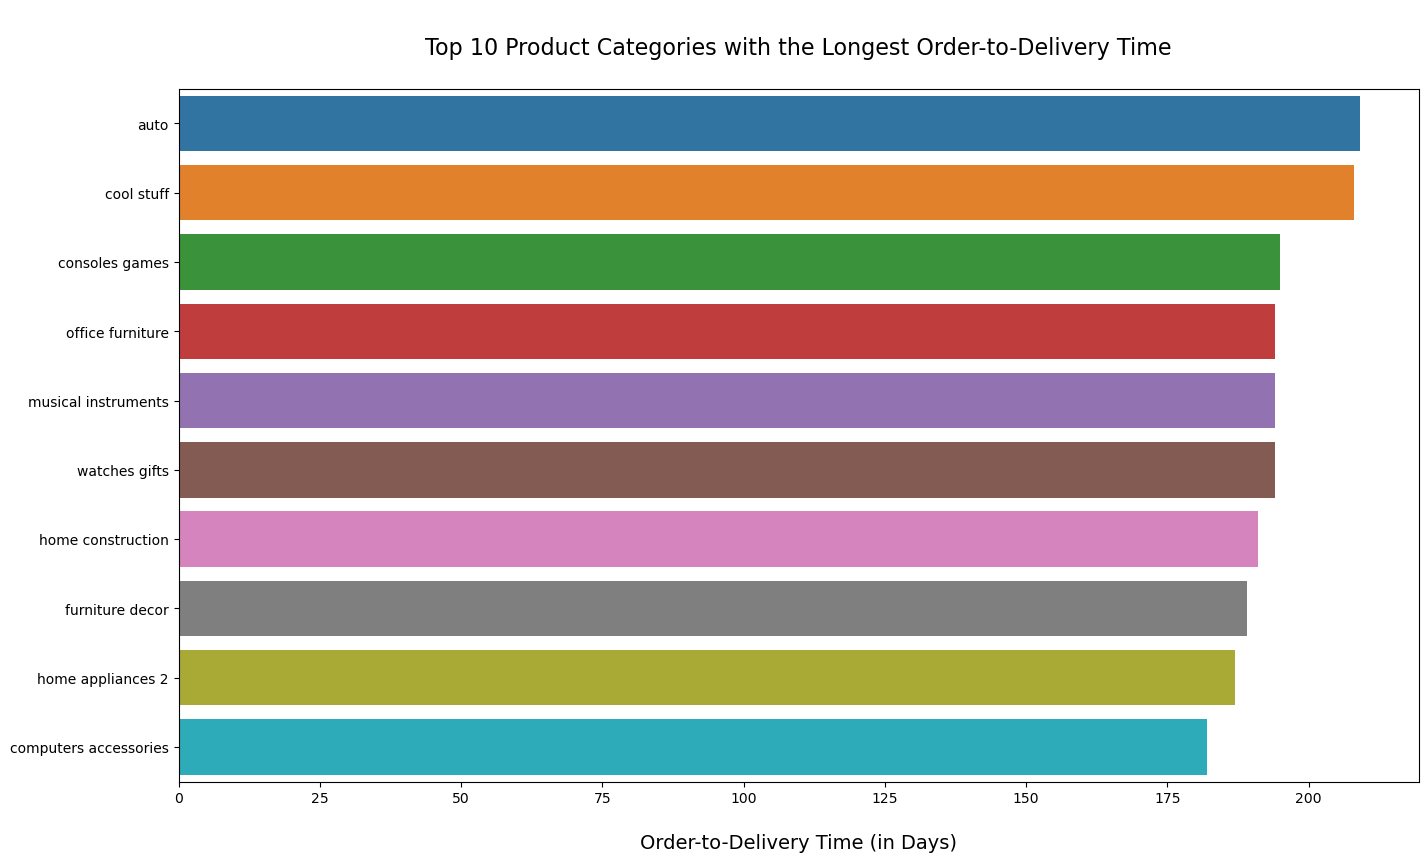

In [193]:
# Plot
fig = plt.figure (figsize = (16,9))
sns.barplot (y = order_time_by_category.index, x = order_time_by_category['order_process_time'].dt.days)
plt.title ('\nTop 10 Product Categories with the Longest Order-to-Delivery Time\n', fontsize = 16)
plt.xlabel('\nOrder-to-Delivery Time (in Days)', fontsize = 14)
plt.ylabel('', fontsize = 14)
plt.show();

### Question 2.7 – Order Volume by Month Over Time

In [194]:
# Order count by month

order_count_by_month = df['order_item_id'].groupby(df['Month_order']).count()

In [195]:
# List the first 5 results.

order_count_by_month.head()

Month_order
2016-09       3
2016-10     384
2016-12       1
2017-01    1010
2017-02    2014
Name: order_item_id, dtype: int64

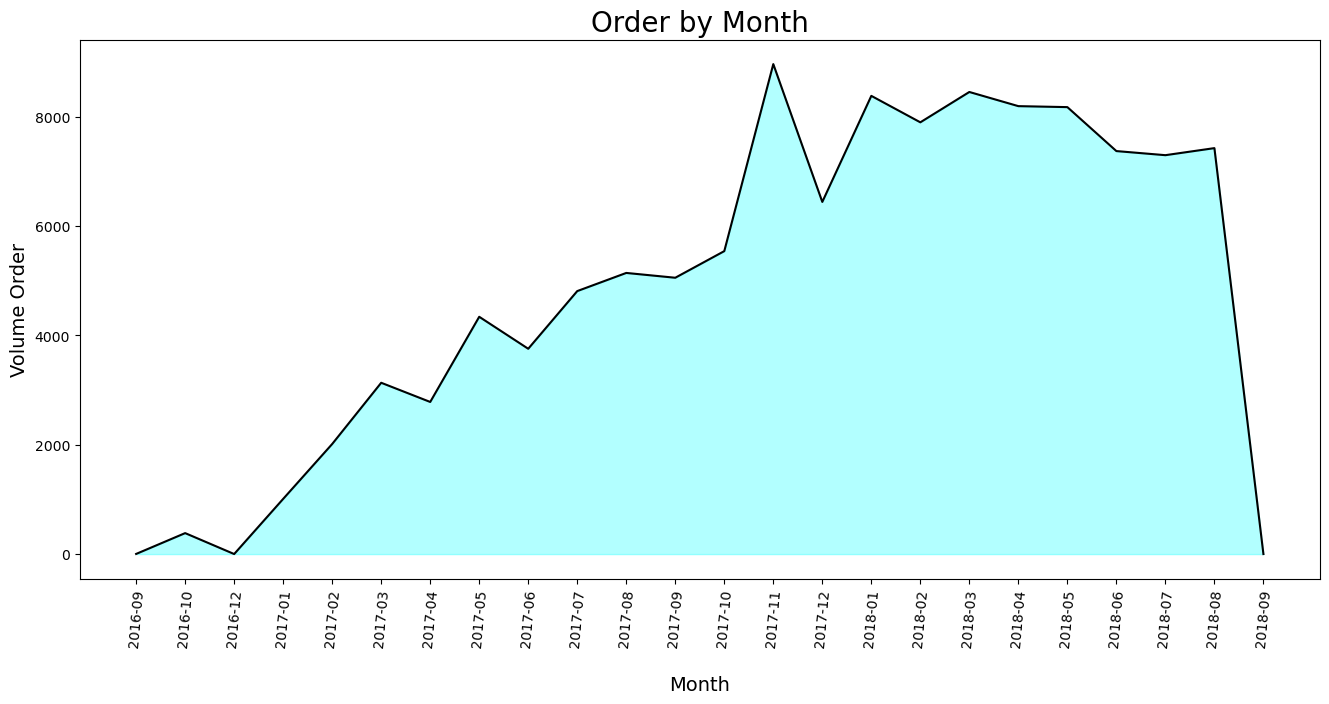

In [196]:
# Plot

plt.figure(figsize = (16,7))
plt.fill_between(order_count_by_month.index, order_count_by_month.values, color = "cyan", alpha = 0.3)
plt.plot(order_count_by_month.index, order_count_by_month.values, color = "black")
plt.title('Order by Month', fontsize = 20)
plt.xlabel('\nMonth', fontsize = 14)
plt.xticks(rotation = 85)
plt.ylabel('Volume Order', fontsize = 14)
plt.show();

### Question 2.8 – Monthly Revenue Over Time

In [197]:
# Monthly Revenue

revenue_count_by_month = df['payment_value'].groupby(df['Month_order']).sum()

In [198]:
# List the first 5 results

revenue_count_by_month.head()

Month_order
2016-09       347.52
2016-10     74677.62
2016-12        19.62
2017-01    187524.53
2017-02    335323.29
Name: payment_value, dtype: float64

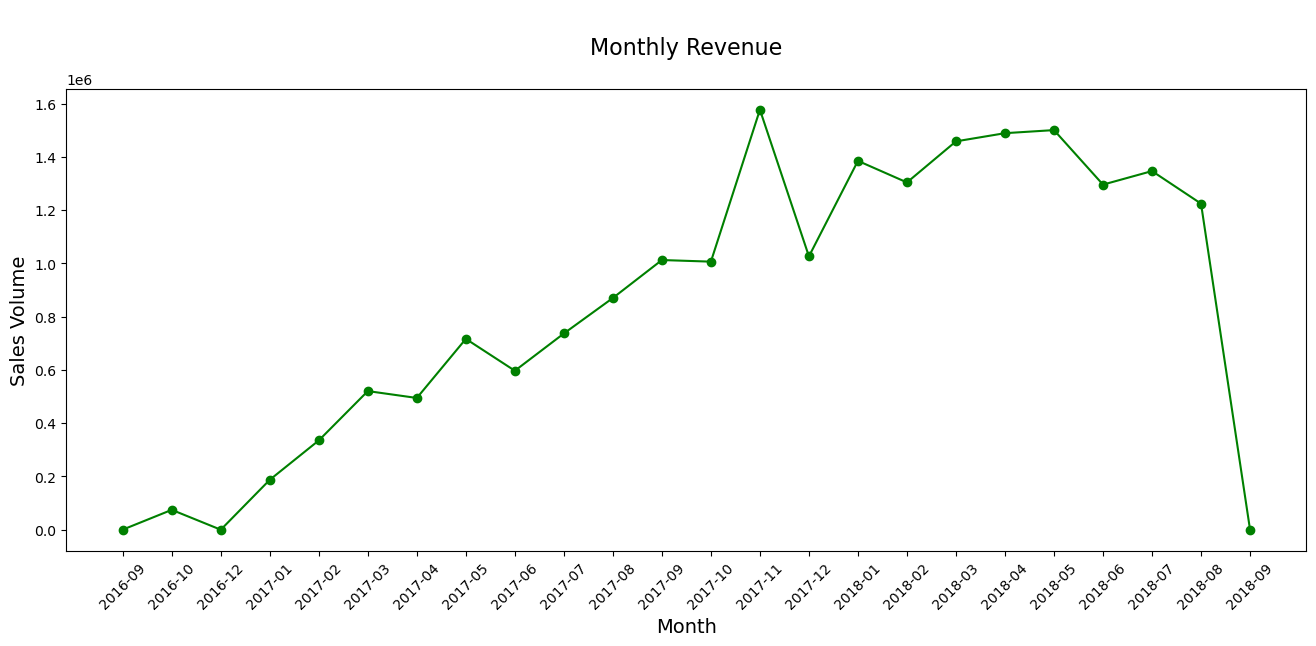

In [199]:
# Plot

fig = plt.figure(figsize = (16,6))
plt.plot(revenue_count_by_month.index, revenue_count_by_month.values, marker = 'o', color = "Green")
plt.title('\nMonthly Revenue\n', fontsize = 16)
plt.xlabel('Month', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Sales Volume', fontsize = 14)
plt.show();

## Section 3 - Payment Analysis

Let’s load another dataset containing payment details and analyze the data.

In [200]:
FILE_ID = "132aVVvkZXFXAtyIYVEXmhL8rD9alKeHt"

url = f"https://drive.google.com/uc?id={FILE_ID}"

df2 = pd.read_csv(url)

In [201]:
df2.sample(10)

,order_id,order_id3,payment_sequential,payment_type,payment_installments,payment_value
21962,ON06305,cd39022e5751efdf258a1052e7e9bc70,1,boleto,1,82.98
73725,ON63119,c2a8cb0a8bf007dbb36ed1c3bda6aeae,1,boleto,1,48.09
64484,ON50623,5c6d04d4860d065452c6ea2d2c82e114,1,credit_card,4,47.13
82451,ON76122,20e7a6f048b842f51258e0b90b76339b,1,credit_card,1,97.86
85461,ON20196,01f78824e3a8e474a36d8dfc2a2c35f4,1,credit_card,1,66.25
41758,ON69510,a2a14c3ce5305a2e20126dac4cd05a1b,1,credit_card,1,30.45
1425,ON26851,1767c122a3ee029a66f97b74a2538d2e,1,credit_card,1,119.84
55981,ON06885,badff059f06914594e6477d1273478db,1,credit_card,6,236.76
79934,ON49052,acf3ac1c437e8674370762c5a482b978,1,credit_card,2,119.00
99116,ON50980,7839ede137c543ee4afd006c5edc2f4c,1,boleto,1,21.15


In [202]:
# Data resume

df2.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


### Changing the Data Scale for Visualization

In [203]:
# Compute the logarithmic value to standardize the data on the same scale

df2['payment_value_log'] = df2['payment_value'].apply(lambda x: np.log(x) if x > 0 else 0)

In [204]:
# Data sample

df2.head()

,order_id,order_id3,payment_sequential,payment_type,payment_installments,payment_value,payment_value_log
0,ON34305,e481f51cbdc54678b7cc49136f2d6af7,1,credit_card,1,18.12,2.897016
1,ON34305,e481f51cbdc54678b7cc49136f2d6af7,3,voucher,1,2.00,0.693147
2,ON34305,e481f51cbdc54678b7cc49136f2d6af7,2,voucher,1,18.59,2.922624
3,ON12238,53cdb2fc8bc7dce0b6741e2150273451,1,boleto,1,141.46,4.952017
4,ON21442,47770eb9100c2d0c44946d9cf07ec65d,1,credit_card,3,179.12,5.188056


In [205]:
# extract unique values

unique_ = df2['order_id'].nunique()

In [206]:
print("DataFrame shape: {}; ids: {}".format(df2.shape, unique_))

DataFrame shape: (103886, 7); ids: 99440


In [207]:
# Function to plot linear and log distribuitions

def plot_dist(values, log_values, title, color = "#D84E32"):
    fig, axis = plt.subplots(1, 2, figsize = (12,4))
    axis[0].set_title("{} - Linear Scale".format(title))
    axis[1].set_title("{} - Log Scale".format(title))
    ax1 = sns.histplot(values, color = color, ax = axis[0])
    ax2 = sns.histplot(log_values, color=color, ax = axis[1])

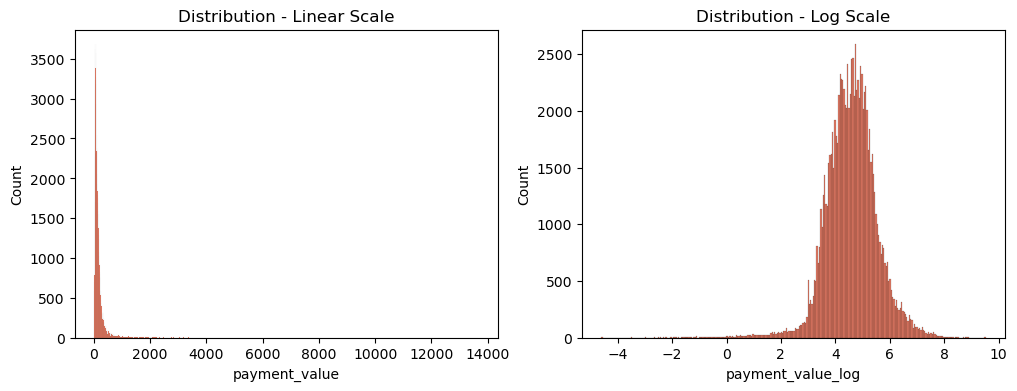

In [208]:
# Plot

plot_dist(df2.payment_value, df2.payment_value_log, "Distribution")

### Question 3.1 – Payment Method Proportions

In [209]:
# Payment Method Proportions

method_count = df2['payment_type'].value_counts().to_frame().reset_index()

In [210]:
method_value = df2.groupby('payment_type')['payment_value'].sum().to_frame().reset_index()

In [211]:
method_count.reset_index(inplace = True)

In [212]:
method_value.reset_index(inplace = True)

> Chart 1

In [213]:
# Plot
colors = None

# Chart 1
trace1 = go.Pie(labels = method_count['index'], 
                values = method_count['payment_type'], 
                domain = {'x': [0, .48]}, 
                marker = dict(colors = colors))

# Chart 2
trace2 = go.Pie(labels = method_value['payment_type'], 
                values = method_value['payment_value'],
                domain = {'x': [0.52, 1]}, 
                marker = dict(colors = colors))

# Layout
layout = dict(title = "Payment Method Proportions", height = 400, width = 800)
fig = go.Figure(data = [trace1, trace2], layout = layout)
fig.show()

> Chart 2

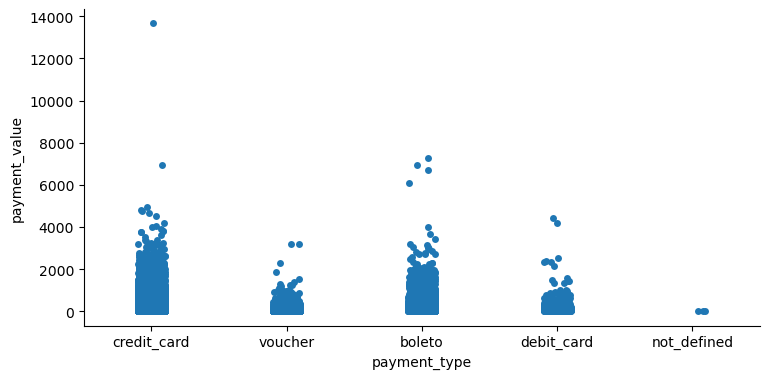

In [214]:
# Payment Scatter Plot

x = sns.catplot(x = "payment_type", y = "payment_value", data = df2, aspect = 2, height = 3.9)

> Chart 3

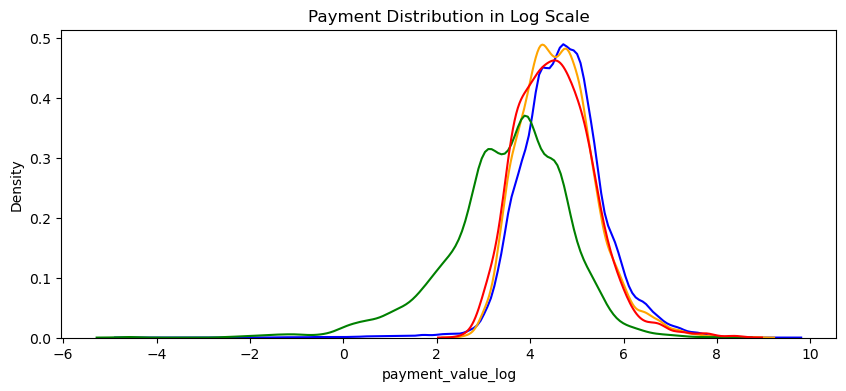

In [215]:
# Payment Distribution in Log Scale

plt.figure(figsize = (10,4))

plt.title("Payment Distribution in Log Scale")

p1 = sns.kdeplot(df2[df2.payment_type == 'credit_card']['payment_value_log'], color = "blue", label = 'Credit card')

p2 = sns.kdeplot(df2[df2.payment_type == 'boleto']['payment_value_log'], color = "orange", label = 'Boleto')

p3 = sns.kdeplot(df2[df2.payment_type == 'voucher']['payment_value_log'], color = "green", label = 'Voucher')

p4 = sns.kdeplot(df2[df2.payment_type == 'debit_card']['payment_value_log'], color = "red", label = 'Debit card')

### Question 3.2 – Number of Installments vs Average Installment Value

In [216]:
df2.head()

,order_id,order_id3,payment_sequential,payment_type,payment_installments,payment_value,payment_value_log
0,ON34305,e481f51cbdc54678b7cc49136f2d6af7,1,credit_card,1,18.12,2.897016
1,ON34305,e481f51cbdc54678b7cc49136f2d6af7,3,voucher,1,2.00,0.693147
2,ON34305,e481f51cbdc54678b7cc49136f2d6af7,2,voucher,1,18.59,2.922624
3,ON12238,53cdb2fc8bc7dce0b6741e2150273451,1,boleto,1,141.46,4.952017
4,ON21442,47770eb9100c2d0c44946d9cf07ec65d,1,credit_card,3,179.12,5.188056


In [217]:
# Payment method used for installment payments.

df2[df2['payment_installments'] > 1]['payment_type'].value_counts().to_frame()

,count
payment_type,
credit_card,51338


In [218]:
# Preparing data

ins_count = df2.groupby('payment_installments').size()
ins_mean = df2.groupby('payment_installments')['payment_value'].mean()

In [219]:
# Plot

# Chart 1
trace0 = go.Bar(x = ins_count.index,
                y = ins_count.values,
                name = 'Number of Installments',
                marker = dict(color  = 'rgb(69,150,119)'))

# Chart 2
trace1 = go.Bar(x = ins_mean.index,
                y = ins_mean.values,
                name = 'Average Installment Value',
                marker = dict(color = 'rgb(24,20,24)'))

# Layout
fig = tools.make_subplots(rows = 1, cols = 2, print_grid = False)
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height = 400, width = 1000, title = 'Installment Payment', legend = dict(orientation = "h"))
fig.show()

When analyzing the distribution of installment counts, clear patterns emerge. Most companies in Brazil offer installment options of up to 10 payments, and the average product value tends to increase as the number of installments rises, up to this threshold. Additionally, installment plans with seven and nine payments appear to be relatively uncommon, suggesting potential consumer or market preferences influencing these options.

### Question 3.3 – Total Sales vs Day of the Week Over Time

In [220]:
# Total Sales vs Day of the Week Over Time

sales_per_purchase_month = df.groupby(['order_purchase_month', 'order_purchase_mon', 'order_purchase_day'], 
                                          as_index = False).payment_value.sum()

In [221]:
# Order by month

sales_per_purchase_month = sales_per_purchase_month.sort_values(by = ['order_purchase_month'], ascending = True)

In [222]:
# Data sample

sales_per_purchase_month.head()

,order_purchase_month,order_purchase_mon,order_purchase_day,payment_value
0,1,Jan,Fri,206844.41
1,1,Jan,Mon,265600.11
2,1,Jan,Sat,165882.44
3,1,Jan,Sun,162629.79
4,1,Jan,Thu,229321.25


In [223]:
# Plot

# Chart
fig = px.line(sales_per_purchase_month, 
              x = "order_purchase_mon", 
              y = "payment_value", 
              color = 'order_purchase_day', 
              title = 'Total Sales vs Day of the Week Over Time')

# Layout
fig.update_layout(title = "Total Sales vs Day of the Week Over Time",
                  xaxis_title = "Months",
                  yaxis_title = "Total Sales Value")
fig.show()

### Question 3.4 - Top 10 Categories by Revenue

In [224]:
# Dataset copy

df3 = df.copy()

In [225]:
# Grouping

sales_per_category = df3.groupby(['order_purchase_mon', 'product_category_name_english'], 
                                 as_index = False).payment_value.sum()[:10]

In [226]:
# Order

sales_per_category = sales_per_category.sort_values(by = ['payment_value'], ascending = False)

In [227]:
# Columns

sales_per_category.columns = ['Purchase Month', 'Product Category', 'Sales Revenue']

In [228]:
# List the first 5 results

sales_per_category.head()

,Purchase Month,Product Category,Sales Revenue
7,Apr,bed bath table,162940.63
5,Apr,auto,90480.93
6,Apr,baby,79162.37
4,Apr,audio,10616.44
8,Apr,books general interest,9386.39


In [229]:
# Plot
fig = px.bar(sales_per_category, 
             y = 'Sales Revenue', 
             x = 'Product Category', 
             text = 'Sales Revenue', 
             hover_data = ['Purchase Month'])
fig.update_traces(texttemplate = '%{text:.2s}', 
                  textposition = 'outside')
fig.update_layout(
    barmode = 'stack', 
    uniformtext_minsize = 8, 
    uniformtext_mode = 'hide', 
    xaxis_tickangle = -75,
    height = 700  
)
fig.update_yaxes(title_text = 'Revenue from Sales')
fig.update_xaxes(title_text = 'Product Category')
fig.show();

## We will continue in the next part: dataviz3 script.